# CSBS Cluster Analysis
Exploratory ML clustering of organisations across CSBS survey waves.


## 1. Import libraries

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

## 2. Load survey data

**Feature groups** are defined upfront using the stable 172-variable core — variables confirmed present and consistently named across all 8 waves. Grouping them here makes the feature set easy to adjust without hunting through the rest of the code.

- `GOVERNANCE_VARS` — six management action variables (`manage1–7`): whether the org carries out key governance practices (risk assessment, defined responsibilities, board oversight, etc.)
- `POLICY_VARS` — seven formal policy variables (`policy1–5, 8, 9`): whether documented security policies exist for key areas
- `CONTROLS_VARS` — the ten technical controls from the 10-Steps to Cyber Security framework (`step1–10`)
- `CLUSTER_FEATURES` — the full 26-variable set used for clustering, including the derived `priority_score` and `breached` columns built in the next step

`normalise_columns()` strips whitespace and BOM characters from column headers and lowercases them — needed because wave files have minor formatting inconsistencies between years.

Files are loaded as tab-delimited text (`.tab` format) using `pd.read_csv(sep='\t')`. The `year` column is synthetic — added at load time so that all waves can be stacked into a single dataframe.

In [73]:
PROJECT_ROOT = Path.cwd().parent

# Feature groups — all stable across all 8 waves (172-variable core)
GOVERNANCE_VARS  = ['manage1', 'manage2', 'manage3', 'manage4', 'manage6', 'manage7']
POLICY_VARS      = ['policy1', 'policy2', 'policy3', 'policy4', 'policy5', 'policy8', 'policy9']
CONTROLS_VARS    = ['step1', 'step2', 'step3', 'step4', 'step5',
                    'step6', 'step7', 'step8', 'step9', 'step10']
CLUSTER_FEATURES = ['priority_score'] + GOVERNANCE_VARS + POLICY_VARS + CONTROLS_VARS + ['breached']

MISSING_CODES = [-1, -97, -98, -99]

def normalise_columns(df):
    """Strip whitespace, remove BOM, lowercase column names."""
    df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=False).str.lower()
    return df

raw = {}
for year in range(2018, 2026):
    path = PROJECT_ROOT / 'data_raw' / f'{year}.tab'
    df = pd.read_csv(path, sep='\t', low_memory=False)
    df = normalise_columns(df)
    df['year'] = year
    raw[year] = df

print(f"Loaded {len(raw)} waves:")
for y, df in raw.items():
    print(f"  {y}: {len(df):,} rows, {df.shape[1]:,} columns")

Loaded 8 waves:
  2018: 2,088 rows, 462 columns
  2019: 2,080 rows, 462 columns
  2020: 1,900 rows, 313 columns
  2021: 2,284 rows, 421 columns
  2022: 2,157 rows, 447 columns
  2023: 3,991 rows, 568 columns
  2024: 3,434 rows, 499 columns
  2025: 3,835 rows, 528 columns


## 3. Clean and engineer features

Several transformations are needed before the data is usable for clustering:

**1. Filter to businesses only**  
`sizeb` (org size: micro/small/medium/large) is only meaningful for `samptype == 1`. Charities and education providers are excluded here to keep the clustering focused on a comparable population with consistent size coding.

**2. Policy routing fix**  
`policy1–5` are coded `-1` (routing/not applicable) when `manage3 == 0` — i.e. the organisation has no formal security policy in place. These `-1` values are *not* missing data — they mean "this policy does not exist". They are recoded to `0` *before* the standard missing-code sweep to preserve this information rather than losing it to NaN.

**3. Standard missing codes → NaN**  
CSBS uses numeric placeholders for non-response: `-1` (routing), `-97` (don't know), `-98` (not asked), `-99` (missing). These are replaced with `NaN` so they don't influence any calculations.

**4. `priority` — 2025 wave quirk**  
In the 2025 wave, don't-know responses at `priority` (board's cyber security priority rating) are coded `997` instead of the standard `-97`. Whitelisting to `{1, 2, 3, 4}` handles this without any wave-specific logic. The scale is then inverted: `priority_score = 5 − priority`, so a higher score means higher board priority.

**5. `type11` — 2025 wave quirk**  
In the 2025 wave, missing values at `type11` are coded `-9`. Whitelisting to `{0, 1}` handles this. `type11 == 0` is the "none of these" response to the attack-type question — meaning the org *did* experience a breach. This is recoded to `breached = 1` for clarity.

> **Sanity check:** the printed breach rates per year should be in the 40–60% range. Values above 90% indicate the missing-code filters have not been applied correctly.

In [74]:
def prepare_wave(df):
    """Filter to businesses, handle missing codes and routing for one wave."""
    df = df.copy()

    # Businesses only — sizeb only meaningful for samptype==1
    df = df[df['samptype'] == 1].copy()

    # Policy routing: policy1–5 are -1 (routing) when manage3==0 (no formal policy)
    # Treat routing -1 as 0 (policy not in place)
    if 'manage3' in df.columns:
        no_policy = df['manage3'] == 0
        for col in ['policy1', 'policy2', 'policy3', 'policy4', 'policy5']:
            if col in df.columns:
                df.loc[no_policy & (df[col] == -1), col] = 0

    # Replace standard missing codes with NaN
    df = df.replace(MISSING_CODES, np.nan)

    # priority: whitelist {1,2,3,4} — excludes 2025 wave's 997 (DK) code
    # Invert: 1=very high priority → score 4; 4=very low priority → score 1
    if 'priority' in df.columns:
        df['priority'] = df['priority'].where(df['priority'].isin([1, 2, 3, 4]))
        df['priority_score'] = 5 - df['priority']

    # type11: whitelist {0,1} — excludes 2025 wave's -9 code
    # type11==0 means breached; recode to breached=1 for clarity
    if 'type11' in df.columns:
        df['type11'] = df['type11'].where(df['type11'].isin([0, 1]))
        df['breached'] = (df['type11'] == 0).astype(float)
        df.loc[df['type11'].isna(), 'breached'] = np.nan

    return df

cleaned = {year: prepare_wave(df) for year, df in raw.items()}

for y, df in cleaned.items():
    breach_pct = df['breached'].mean() * 100 if 'breached' in df else float('nan')
    print(f"  {y}: {len(df):,} businesses | breach rate {breach_pct:.1f}%")

  2018: 1,519 businesses | breach rate 52.1%
  2019: 1,615 businesses | breach rate 42.1%
  2020: 1,374 businesses | breach rate 57.5%
  2021: 1,448 businesses | breach rate 47.2%
  2022: 1,265 businesses | breach rate 47.3%
  2023: 2,413 businesses | breach rate 41.2%
  2024: 2,000 businesses | breach rate 57.6%
  2025: 2,180 businesses | breach rate 53.5%


## 4. Build feature matrix

Rather than using all numeric columns (which would pull in hundreds of irrelevant variables), only the 26 pre-defined `CLUSTER_FEATURES` are selected. This keeps the clustering focused on theoretically meaningful dimensions of cyber security behaviour.

`META_COLS` (`year`, `sizeb`) are carried alongside the features but are **not** passed to the clustering algorithm — they are used afterwards for interpreting and segmenting the results (e.g. "what size orgs dominate each cluster?").

The feature availability table is a diagnostic: any variable below ~70% non-null may introduce imputation bias. `priority_score` (~75%) is the most sparse, driven by legitimate don't-know responses, and is handled by median imputation in the next step.

In [75]:
META_COLS = ['year', 'sizeb']

frames = []
for year, df in cleaned.items():
    cols = [c for c in CLUSTER_FEATURES + META_COLS if c in df.columns]
    frames.append(df[cols])

combined = pd.concat(frames, ignore_index=True)

print(f"Combined dataset: {len(combined):,} rows\n")
print("Feature availability (non-null rate):")
print(combined[CLUSTER_FEATURES].notna().mean().round(3).to_string())

Combined dataset: 13,814 rows

Feature availability (non-null rate):
priority_score    0.749
manage1           0.957
manage2           0.952
manage3           1.000
manage4           0.957
manage6           1.000
manage7           1.000
policy1           1.000
policy2           1.000
policy3           1.000
policy4           1.000
policy5           1.000
policy8           0.474
policy9           0.474
step1             1.000
step2             1.000
step3             1.000
step4             1.000
step5             1.000
step6             1.000
step7             1.000
step8             1.000
step9             1.000
step10            1.000
breached          1.000


## 5. Impute missing values

K-Means cannot operate on `NaN` values — rows with any missing value would need to be dropped entirely, losing thousands of valid respondents. `SimpleImputer` replaces each `NaN` with the **median** of that feature across all rows.

**Why median rather than mean?**  
Most features are binary (0/1) or short ordinal scales. The median is more robust to skewed distributions and is a sensible central value for these types.

**Why not just drop incomplete rows?**  
`priority_score` is missing for ~25% of respondents (legitimate don't-know responses at Q9). Dropping those rows would introduce selection bias — organisations that decline to rate their board's priority are likely systematically different from those that do.

In [76]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(combined[CLUSTER_FEATURES])

print(f"Feature matrix: {X_imputed.shape}")
print(f"Missing values after imputation: {np.isnan(X_imputed).sum()}")

Feature matrix: (13814, 25)
Missing values after imputation: 0


## 6. Standardise features

K-Means assigns observations to clusters using **Euclidean distance**. Features on larger scales would dominate the distance calculation if left unstandardised — for example, `priority_score` (range 1–4) would outweigh binary (0/1) step variables simply due to its larger numeric range.

`StandardScaler` transforms each feature to **mean = 0, standard deviation = 1**, ensuring every variable contributes equally regardless of its original scale.

> The scaler is fit on the full pooled dataset (all 8 waves combined). `X` is the standardised matrix passed to K-Means; `combined` retains the original unscaled values for interpreting cluster profiles afterwards.

In [77]:
scaler = StandardScaler()
X = scaler.fit_transform(X_imputed)

print(f"Standardised X: {X.shape}")

Standardised X: (13814, 25)


## 7. Find optimal K (elbow method)

K-Means requires you to specify the number of clusters (`K`) in advance. The **elbow method** helps choose a sensible value by plotting *inertia* (total within-cluster sum of squared distances) for K = 2 to 10.

- As K increases, inertia always falls — more clusters always fit the data better by definition
- The **elbow** is where adding another cluster gives sharply diminishing returns
- The right K sits at the bend in the curve — beyond it, the improvement is marginal

**K = 4 as a starting point** — the README proposes four archetypes (Security Leaders, Compliance Driven, Reactive, Low Awareness). Adjust the `K = 4` line below the plot if the elbow suggests a different value.

**`n_init=10`** — K-Means is sensitive to random initialisation. Running 10 initialisations and taking the best reduces the chance of landing in a poor local minimum. Cluster assignments are stored back into `combined['cluster']` so they travel alongside the original feature values.

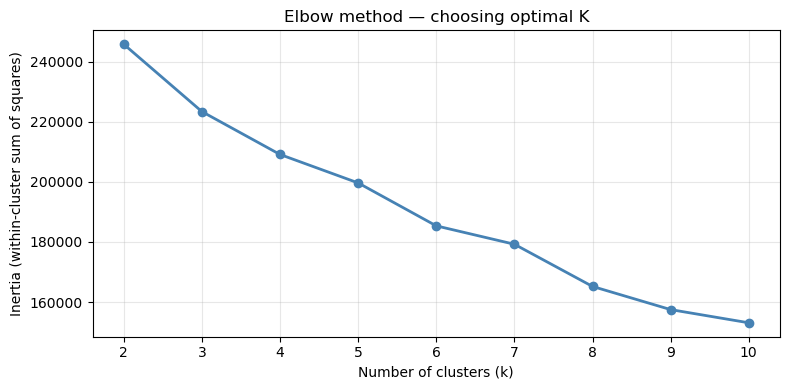


Cluster sizes (K=4):
cluster
0    5570
1    3089
2    4847
3     308
Name: count, dtype: int64


In [78]:
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow method — choosing optimal K')
plt.xticks(list(K_range))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'ml_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

# Fit final model — adjust K based on elbow above
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
combined['cluster'] = kmeans.fit_predict(X)

print(f"\nCluster sizes (K={K}):")
print(combined['cluster'].value_counts().sort_index())

## 8. Cluster profiles

The profile table summarises each cluster by its mean score across five grouped dimensions:

| Dimension | What a high value means |
|---|---|
| **Priority score (1–4)** | Board rates cyber security as a higher priority |
| **Governance (mean)** | More governance actions in place (risk assessments, defined responsibilities, etc.) |
| **Policy (mean)** | More formal, documented security policies |
| **Controls (mean)** | More technical controls from the 10-Steps framework adopted |
| **Breach rate (%)** | Higher proportion of orgs in this cluster reported a breach |

The key interpretive question is whether orgs with stronger governance and controls experience *fewer* breaches. If the cluster with the highest governance/controls score also has the lowest breach rate, that supports the protective-measures narrative.

Cluster numbers (0, 1, 2, 3) are arbitrary — rename them after reviewing the profiles and the heatmap below.

In [79]:
profile = pd.DataFrame({
    'Priority score (1–4)': combined.groupby('cluster')['priority_score'].mean(),
    'Governance (mean)':    combined.groupby('cluster')[GOVERNANCE_VARS].mean().mean(axis=1),
    'Policy (mean)':        combined.groupby('cluster')[POLICY_VARS].mean().mean(axis=1),
    'Controls (mean)':      combined.groupby('cluster')[CONTROLS_VARS].mean().mean(axis=1),
    'Breach rate (%)':      combined.groupby('cluster')['breached'].mean() * 100,
    'Count':                combined.groupby('cluster').size(),
})

print("Cluster profiles:\n")
print(profile.round(2).to_string())

Cluster profiles:

         Priority score (1–4)  Governance (mean)  Policy (mean)  Controls (mean)  Breach rate (%)  Count
cluster                                                                                                 
0                        3.62               0.51           0.57             0.82            62.81   5570
1                        2.56               0.17           0.05             0.22            27.45   3089
2                        3.27               0.27           0.07             0.47            49.68   4847
3                        3.25               0.17           0.00             0.27            32.79    308


## 9. Interpreting the clusters

K-Means groups organisations by similarity across the 26 feature variables (governance, policy, controls, breach outcome). It doesn't label the clusters — **you assign meaning based on what you observe**.

**How to read the outputs below:**

| Output | What it tells you |
|---|---|
| **Profiles table** (above) | The average scores for each cluster across the five dimensions |
| **Feature heatmap** | Which clusters score high/low on governance, controls, policy, and breach rate — this is how you name them |
| **Org size breakdown** | Whether a cluster is dominated by micro businesses, large orgs, etc. |
| **Cluster share by year** | Whether a cluster grows or shrinks over time — i.e. is the population improving? |
| **Radar chart** | Visual shape of each cluster's "security profile" |
| **PCA scatter** | Shows how well-separated the clusters are (tighter = more distinct) |

**Naming clusters (do this after running):** Look at the heatmap. A cluster with high governance + high controls + low breach = "Security Leaders". High breach + low controls = "Low Awareness". Use the README's suggested archetypes as a starting point.

In [80]:
# Who is in each cluster? — breakdown by org size
size_labels = {1: 'Micro (<10)', 2: 'Small (10–49)', 3: 'Medium (50–249)', 4: 'Large (250+)'}
combined['size_label'] = combined['sizeb'].map(size_labels)

print("=" * 65)
print("What % of each cluster is made up of each org size?")
print("(reads across rows — tells you the composition of each cluster)")
print("=" * 65)
ct = pd.crosstab(combined['cluster'], combined['size_label'], normalize='index') * 100
print(ct.round(1).to_string())

print("\n" + "=" * 65)
print("Where does each org size end up? (% assigned to each cluster)")
print("(reads across rows — tells you where each size group concentrates)")
print("=" * 65)
ct2 = pd.crosstab(combined['size_label'], combined['cluster'], normalize='index') * 100
print(ct2.round(1).to_string())

print("\n" + "=" * 65)
print("Raw counts: org size × cluster")
print("=" * 65)
print(pd.crosstab(combined['size_label'], combined['cluster'], margins=True).to_string())

What % of each cluster is made up of each org size?
(reads across rows — tells you the composition of each cluster)
size_label  Large (250+)  Medium (50–249)  Micro (<10)  Small (10–49)
cluster                                                              
0                   21.8             24.5         28.7           25.0
1                    1.4              3.6         79.8           15.2
2                    7.1             12.9         57.1           22.9
3                   10.1             14.9         54.2           20.8

Where does each org size end up? (% assigned to each cluster)
(reads across rows — tells you where each size group concentrates)
cluster             0     1     2    3
size_label                            
Large (250+)     74.5   2.6  21.0  1.9
Medium (50–249)  63.6   5.2  29.0  2.1
Micro (<10)      22.8  35.2  39.6  2.4
Small (10–49)    45.9  15.4  36.6  2.1

Raw counts: org size × cluster
cluster             0     1     2    3    All
size_label            

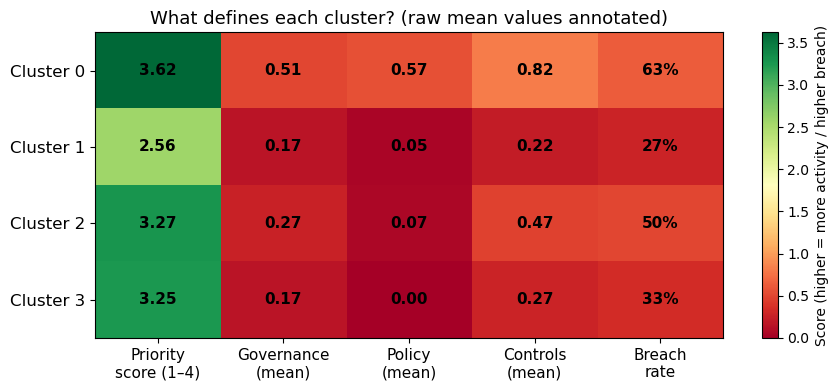

In [81]:
# Feature heatmap — what defines each cluster?
dim_means = pd.DataFrame({
    'Priority\nscore (1–4)': combined.groupby('cluster')['priority_score'].mean(),
    'Governance\n(mean)':    combined.groupby('cluster')[GOVERNANCE_VARS].mean().mean(axis=1),
    'Policy\n(mean)':        combined.groupby('cluster')[POLICY_VARS].mean().mean(axis=1),
    'Controls\n(mean)':      combined.groupby('cluster')[CONTROLS_VARS].mean().mean(axis=1),
    'Breach\nrate':          combined.groupby('cluster')['breached'].mean(),
})

fig, ax = plt.subplots(figsize=(9, 4))
# Use RdYlGn but note: for Breach rate, green = high breach (visually inverted — read annotation)
im = ax.imshow(dim_means.values, cmap='RdYlGn', aspect='auto', vmin=0)

ax.set_xticks(range(len(dim_means.columns)))
ax.set_xticklabels(dim_means.columns, fontsize=11)
ax.set_yticks(range(len(dim_means)))
ax.set_yticklabels([f'Cluster {i}' for i in dim_means.index], fontsize=12)

for i in range(len(dim_means)):
    for j, col in enumerate(dim_means.columns):
        val = dim_means.iloc[i, j]
        fmt = f'{val:.0%}' if 'Breach' in col else f'{val:.2f}'
        ax.text(j, i, fmt, ha='center', va='center', fontsize=11, fontweight='bold')

plt.colorbar(im, ax=ax, label='Score (higher = more activity / higher breach)')
ax.set_title('What defines each cluster? (raw mean values annotated)', fontsize=13)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'ml_profile_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Visualisations

### Radar chart

Shows the same cluster profiles as the table above but as overlapping polygons on five axes — one axis per dimension (priority, governance, policy, controls, breach rate). Values are normalised 0–1 *relative to the range across clusters*, so all five dimensions fit on the same scale.

**How to read it:**
- A cluster that fills a large area = consistently high scores across all dimensions
- An irregular polygon = strong in some areas, weak in others (e.g. good controls but low governance)
- Clusters that overlap heavily are similar; distinct shapes indicate well-differentiated groups

> The normalisation is relative — it only shows differences *between* clusters, not absolute levels. Use the profile table for actual values.

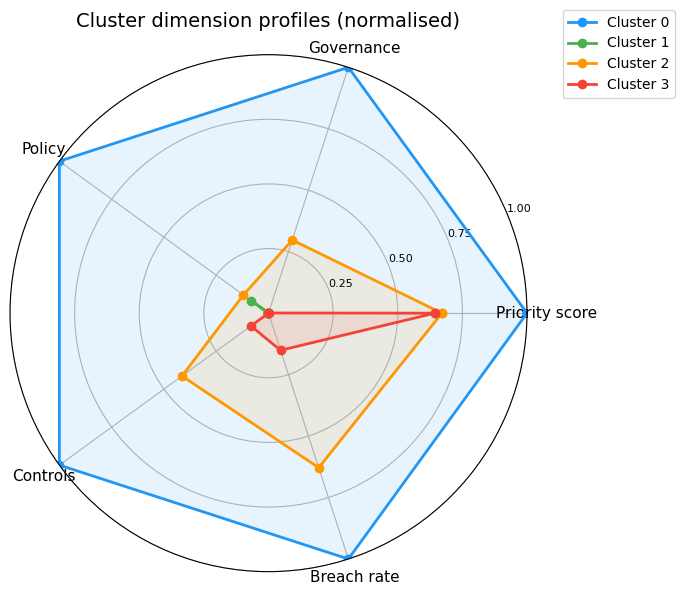

In [82]:
# Radar chart — cluster dimension profiles
dimensions = ['Priority score', 'Governance', 'Policy', 'Controls', 'Breach rate']

dim_data = pd.DataFrame({
    'Priority score': combined.groupby('cluster')['priority_score'].mean(),
    'Governance':     combined.groupby('cluster')[GOVERNANCE_VARS].mean().mean(axis=1),
    'Policy':         combined.groupby('cluster')[POLICY_VARS].mean().mean(axis=1),
    'Controls':       combined.groupby('cluster')[CONTROLS_VARS].mean().mean(axis=1),
    'Breach rate':    combined.groupby('cluster')['breached'].mean(),
})

# Normalise each dimension 0–1 across clusters
dim_norm = (dim_data - dim_data.min()) / (dim_data.max() - dim_data.min()).replace(0, 1)

N = len(dimensions)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close loop

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

for i, (idx, row) in enumerate(dim_norm.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=colors[i], label=f'Cluster {i}')
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dimensions, size=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], size=8)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.set_title('Cluster dimension profiles (normalised)', size=14, pad=20)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'ml_radar.png', dpi=150, bbox_inches='tight')
plt.show()

### Cluster share by year

Shows what proportion of businesses in each survey wave belong to each cluster. Because CSBS is **repeated cross-sectional data** (different respondents each year), this does not track the same organisations over time — it shows whether the *distribution of organisation types* shifts across waves.

**What to look for:**
- A growing share of the high-governance cluster → the population of UK businesses is maturing in cyber security
- A spike in the low-awareness cluster in a particular year → sample composition changed, or an external event affected that cohort
- Stable proportions year-on-year → the distribution of cyber security maturity is not improving

> If shares change dramatically between years, cross-reference the size composition panel in section 10 — a shift in micro vs large business representation can move cluster shares independently of any real behavioural change.

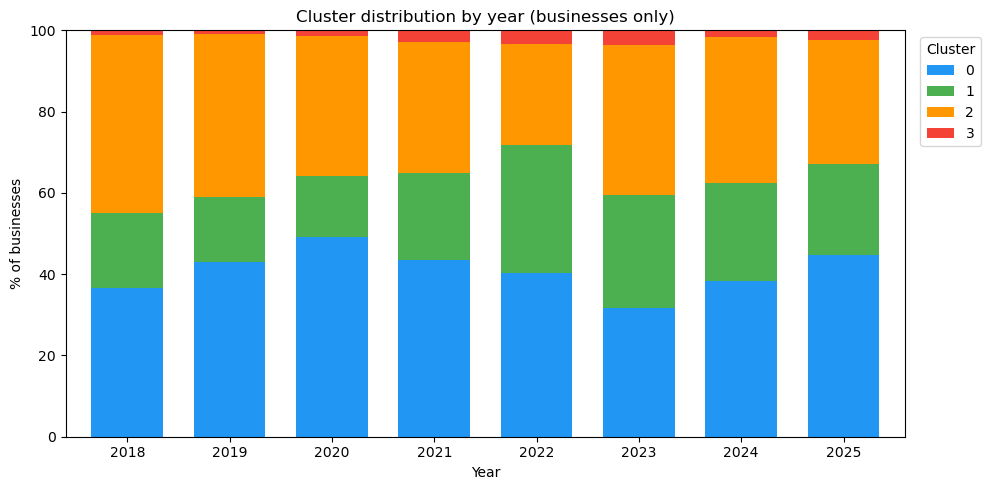


Cluster share by year (%):
cluster     0     1     2    3
year                          
2018     36.6  18.4  43.9  1.1
2019     43.0  15.9  40.1  1.0
2020     49.2  14.8  34.5  1.5
2021     43.4  21.5  32.3  2.8
2022     40.3  31.5  24.7  3.4
2023     31.8  27.7  36.9  3.6
2024     38.2  24.2  36.0  1.6
2025     44.6  22.4  30.6  2.4


In [83]:
# Cluster share by year — how the distribution shifts across waves
share = (combined.groupby(['year', 'cluster'])
         .size()
         .unstack(fill_value=0))
share_pct = share.div(share.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
share_pct.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.7)

ax.set_xlabel('Year')
ax.set_ylabel('% of businesses')
ax.set_title('Cluster distribution by year (businesses only)')
ax.set_xticklabels(share_pct.index, rotation=0)
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'ml_cluster_share.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCluster share by year (%):")
print(share_pct.round(1).to_string())

### PCA scatter plot

Principal Component Analysis reduces the 25-dimensional feature space to 2 dimensions so the cluster assignments can be visualised as a scatter plot. Each point is one organisation, coloured by its cluster.

**How to read it:**
- **Well-separated blobs** → clusters are genuinely distinct; K-Means found meaningful groupings
- **Overlapping blobs** → cluster boundaries are fuzzy; K may be too high, or the underlying groups are not well-separated in this data
- **% variance explained** on the axis labels shows how faithfully the 2D projection represents the full 25-dimensional space — higher percentages = more reliable picture

> PCA is used only for visualisation here. The actual clustering was performed on all 25 standardised features, not on the PCA components.

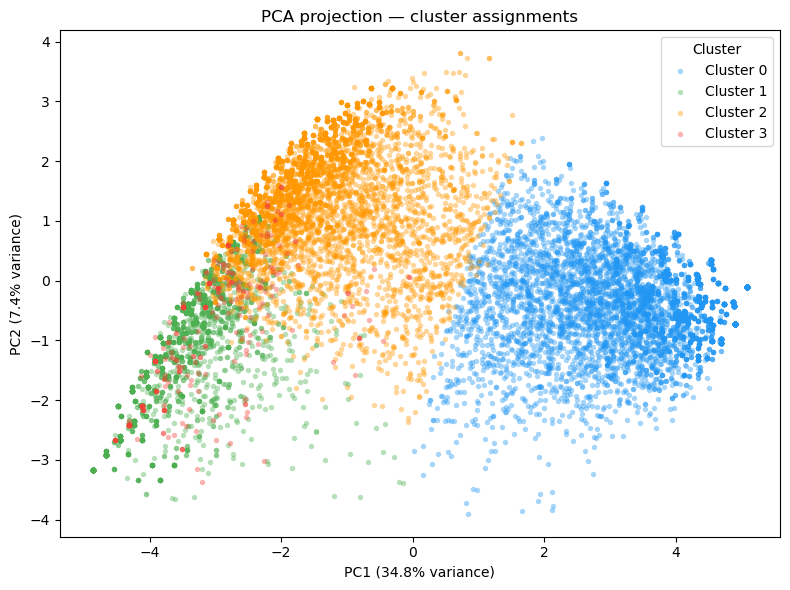

In [84]:
# PCA 2D projection coloured by cluster
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

for i in range(K):
    mask = combined['cluster'] == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[i], label=f'Cluster {i}',
               alpha=0.4, s=15, linewidths=0)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA projection — cluster assignments')
ax.legend(title='Cluster')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'ml_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Breach rate trends and potential drivers over time

Six panels, all on the same x-axis (year), businesses only:

| Panel | What it shows | Why it matters |
|---|---|---|
| **Breach rate** | % of businesses reporting a breach each year | The outcome we're trying to explain |
| **Board priority** | % rating cyber security as high or very high priority | Does board engagement track with or precede breach changes? |
| **Policy adoption** | Mean across 7 policy variables | Are organisations formalising security over time? |
| **Technical controls** | Mean across 10-Steps variables | Is control adoption improving? |
| **Staff training** | % with cyber training (2021+ only) | Does training correlate with lower breach rates? |
| **Sample composition** | % micro / small / medium / large each year | If the mix shifts (e.g. more micros), that alone can move the breach rate |

> **Note:** These are unweighted figures from the raw survey responses. For nationally representative estimates, use the weighted aggregations in `outputs/tables/`. The purpose here is to explore patterns within the ML dataset.

This cell aggregates each cleaned wave into a single row of yearly summary statistics. It pulls from `cleaned` (the per-wave dictionary before feature selection), which means it can access variables not in `CLUSTER_FEATURES` — such as `trained`.

Key decisions:
- **`priority` whitelisting** is applied again here (`{1, 2, 3, 4}`) to correctly compute `board_high_pct` (% rating priority as high or very high) and exclude 2025's `997` DK code
- **Policy and controls** are averaged across all available variables for that wave, giving a 0–1 mean that is later multiplied by 100 for the % scale visualisation
- **`trained`** is only present in 2021–2025; the `if 'trained' in df.columns` guard handles earlier waves cleanly
- **Size composition** is computed as % of valid (non-null) `sizeb` responses, producing four columns (`pct_micro` through `pct_large`) that sum to 100% per year

In [85]:
# Build yearly trend summary from cleaned waves (businesses only)
trend_rows = []

for year, df in cleaned.items():
    row = {'year': year, 'n': len(df)}

    # Breach rate
    if 'breached' in df.columns:
        row['breach_pct'] = df['breached'].mean() * 100

    # Board priority: % rating high or very high (priority in {1, 2})
    if 'priority' in df.columns:
        valid_p = df['priority'].where(df['priority'].isin([1, 2, 3, 4]))
        row['board_high_pct'] = valid_p.isin([1, 2]).sum() / valid_p.notna().sum() * 100

    # Policy adoption: mean across available policy vars
    avail_policy = [c for c in POLICY_VARS if c in df.columns]
    if avail_policy:
        row['policy_mean'] = df[avail_policy].mean().mean()

    # Technical controls: mean across available step vars
    avail_controls = [c for c in CONTROLS_VARS if c in df.columns]
    if avail_controls:
        row['controls_mean'] = df[avail_controls].mean().mean()

    # Training: only exists 2021–2025
    if 'trained' in df.columns:
        t = df['trained'].where(df['trained'].isin([0, 1]))
        row['trained_pct'] = t.mean() * 100

    # Org size composition
    if 'sizeb' in df.columns:
        total = df['sizeb'].notna().sum()
        for code, label in [(1,'micro'), (2,'small'), (3,'medium'), (4,'large')]:
            row[f'pct_{label}'] = (df['sizeb'] == code).sum() / total * 100

    trend_rows.append(row)

trends = pd.DataFrame(trend_rows).set_index('year')
print("Yearly trend summary:\n")
print(trends.round(1).to_string())

Yearly trend summary:

         n  breach_pct  board_high_pct  policy_mean  controls_mean  pct_micro  pct_small  pct_medium  pct_large  trained_pct
year                                                                                                                        
2018  1519        52.1            81.5          0.2            0.6       43.1       23.0        17.3       16.6          NaN
2019  1615        42.1            86.1          0.3            0.6       47.7       20.4        18.6       13.3          NaN
2020  1374        57.5            87.8          0.3            0.7       46.9       20.8        16.2       16.1          NaN
2021  1448        47.2            85.0          0.3            0.6       51.5       19.0        15.1       14.4        100.0
2022  1265        47.3            87.7          0.2            0.5       55.2       21.5        12.2       11.1        100.0
2023  2413        41.2            79.3          0.2            0.5       58.5       18.9        12.8  

Six panels on a shared year x-axis — one per potential driver. Keeping them separate makes it easy to see the shape of each trend individually before comparing them in the overlay. All y-axes are fixed at 0–100% for a consistent visual scale.

**Panel notes:**
- *Breach rate* — the outcome variable; all other panels are potential explanatory factors
- *Board priority* — the % whitelisted to `{1, 2}` (high or very high); a declining trend here would suggest boards are deprioritising cyber security
- *Policy and controls* — unweighted means converted to %; lower absolute values are expected since these are averages across multiple binary variables, not single %s
- *Training* — shows flat 100% for 2021–2025 in the unweighted business subsample; this is worth investigating with weighted estimates if training is a key focus
- *Size composition* — if the micro business share is rising, that alone can depress governance/controls averages and inflate breach rates, since micro orgs tend to have lower maturity

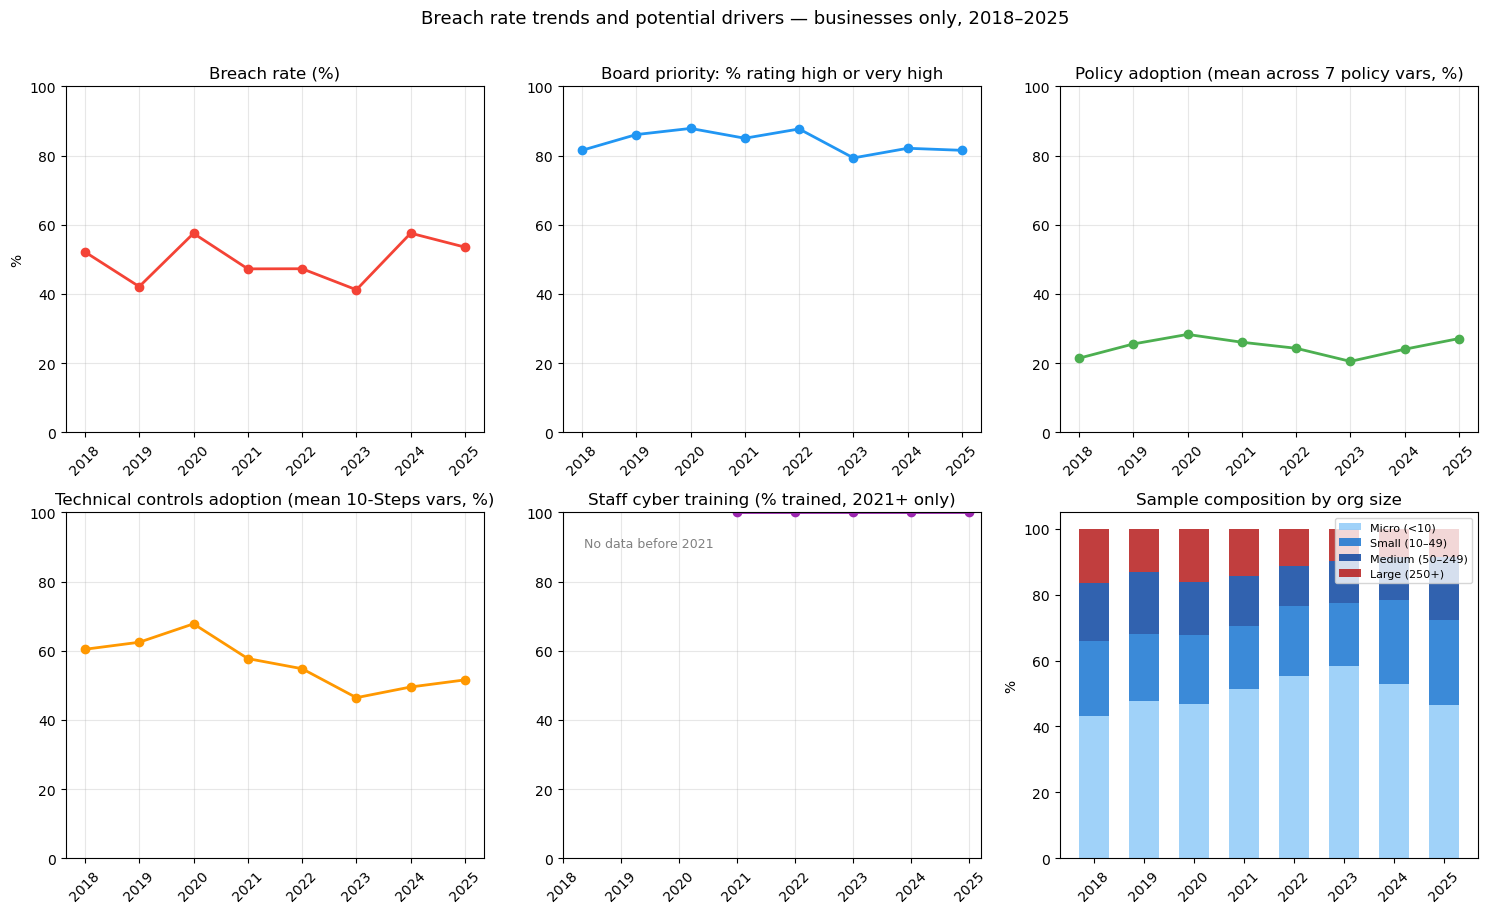

In [86]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
years = trends.index.tolist()

# 1 — Breach rate
ax = axes[0, 0]
ax.plot(years, trends['breach_pct'], marker='o', color='#F44336', linewidth=2)
ax.set_title('Breach rate (%)')
ax.set_ylabel('%')
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)

# 2 — Board priority (% rating high/very high)
ax = axes[0, 1]
ax.plot(years, trends['board_high_pct'], marker='o', color='#2196F3', linewidth=2)
ax.set_title('Board priority: % rating high or very high')
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)

# 3 — Policy adoption
ax = axes[0, 2]
ax.plot(years, trends['policy_mean'] * 100, marker='o', color='#4CAF50', linewidth=2)
ax.set_title('Policy adoption (mean across 7 policy vars, %)')
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)

# 4 — Technical controls
ax = axes[1, 0]
ax.plot(years, trends['controls_mean'] * 100, marker='o', color='#FF9800', linewidth=2)
ax.set_title('Technical controls adoption (mean 10-Steps vars, %)')
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)

# 5 — Training (2021+ only)
ax = axes[1, 1]
trained_data = trends['trained_pct'].dropna()
if not trained_data.empty:
    ax.plot(trained_data.index, trained_data.values, marker='o', color='#9C27B0', linewidth=2)
ax.set_title('Staff cyber training (% trained, 2021+ only)')
ax.set_ylim(0, 100)
ax.text(0.05, 0.93, 'No data before 2021', transform=ax.transAxes,
        fontsize=9, color='grey', va='top')
ax.grid(alpha=0.3)

# 6 — Sample composition by org size
ax = axes[1, 2]
size_cols   = ['pct_micro', 'pct_small', 'pct_medium', 'pct_large']
size_labels = ['Micro (<10)', 'Small (10–49)', 'Medium (50–249)', 'Large (250+)']
size_colors = ['#90CAF9', '#1976D2', '#0D47A1', '#B71C1C']
bottom = np.zeros(len(years))
for col, label, color in zip(size_cols, size_labels, size_colors):
    if col in trends.columns:
        vals = trends[col].fillna(0).values
        ax.bar(years, vals, bottom=bottom, label=label, color=color, alpha=0.85, width=0.6)
        bottom += vals
ax.set_title('Sample composition by org size')
ax.set_ylabel('%')
ax.legend(fontsize=8, loc='upper right')

for row in axes:
    for ax in row:
        ax.set_xticks(years)
        ax.set_xticklabels(years, rotation=45)

fig.suptitle('Breach rate trends and potential drivers — businesses only, 2018–2025',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'ml_breach_trends.png', dpi=150, bbox_inches='tight')
plt.show()

The overlay places all four driver lines on a single chart with the org-size stacked bars as a background context layer. This makes it easier to spot co-movement — e.g. if breach rate and board priority both dip in the same year, or if breach rate tracks the % micro businesses (which would suggest sample composition is driving the trend rather than genuine behavioural change).

**Design choices:**
- Stacked bars use a light-to-dark blue palette at 50% opacity so the lines remain clearly legible on top
- Lines use `zorder=3` to render above both the bars and the grid
- Policy and controls means are multiplied by 100 to bring them onto the same 0–100% axis as breach rate and board priority

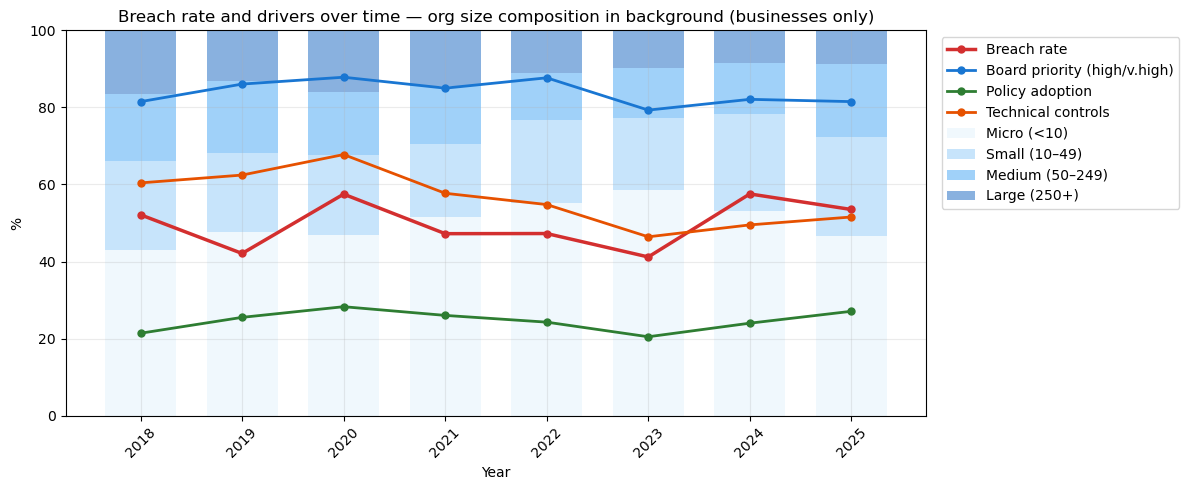

In [87]:
# Overlay — stacked size bars in background, driver lines on top
fig, ax = plt.subplots(figsize=(12, 5))

years = trends.index.tolist()

# --- Background: stacked bars for org size composition ---
size_cols   = ['pct_micro', 'pct_small', 'pct_medium', 'pct_large']
size_labels = ['Micro (<10)', 'Small (10–49)', 'Medium (50–249)', 'Large (250+)']
size_colors = ['#E3F2FD', '#90CAF9', '#42A5F5', '#1565C0']
bottom = np.zeros(len(years))
for col, label, color in zip(size_cols, size_labels, size_colors):
    if col in trends.columns:
        vals = trends[col].fillna(0).values
        ax.bar(years, vals, bottom=bottom, label=label, color=color,
               alpha=0.5, width=0.7, zorder=1)
        bottom += vals

# --- Foreground: driver lines ---
lines = [
    ('breach_pct',     'Breach rate',                '#D32F2F', '-',  2.5),
    ('board_high_pct', 'Board priority (high/v.high)','#1976D2', '-',  2),
    ('policy_mean',    'Policy adoption',             '#2E7D32', '-',  2),
    ('controls_mean',  'Technical controls',          '#E65100', '-',  2),
]

for col, label, color, ls, lw in lines:
    if col not in trends.columns:
        continue
    vals = trends[col].copy()
    if col in ('policy_mean', 'controls_mean'):
        vals = vals * 100
    ax.plot(years, vals, marker='o', label=label,
            color=color, linestyle=ls, linewidth=lw, markersize=5, zorder=3)

ax.set_xlabel('Year')
ax.set_ylabel('%')
ax.set_ylim(0, 100)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=True)
ax.grid(alpha=0.25, zorder=2)
ax.set_title('Breach rate and drivers over time — org size composition in background (businesses only)')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'ml_breach_overlay.png', dpi=150, bbox_inches='tight')
plt.show()